In [1]:
import numpy as np
import pandas as pd
import nibabel as nib
from scipy import ndimage
from nilearn import image
from nilearn import signal
from nilearn import masking
from nilearn import plotting
from nilearn import interfaces
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

In [2]:
baseline_dce_mean = nib.load(r'Z:/2023 VNSiSVD/data/data_neuroimage_DCE/processed/002_spm12_realign&seg/baseline/meant1_vibe_cor_dynamic_waterext_12.nii')
baseline_dce_mean_mask_gm = nib.load(r'Z:/2023 VNSiSVD/data/data_neuroimage_DCE/processed/002_spm12_realign&seg/baseline/c1meant1_vibe_cor_dynamic_waterext_12.nii')
baseline_dce_mean_mask_wm = nib.load(r'Z:/2023 VNSiSVD/data/data_neuroimage_DCE/processed/002_spm12_realign&seg/baseline/c2meant1_vibe_cor_dynamic_waterext_12.nii')
baseline_dce_mean_mask_csf = nib.load(r'Z:/2023 VNSiSVD/data/data_neuroimage_DCE/processed/002_spm12_realign&seg/baseline/c3meant1_vibe_cor_dynamic_waterext_12.nii')

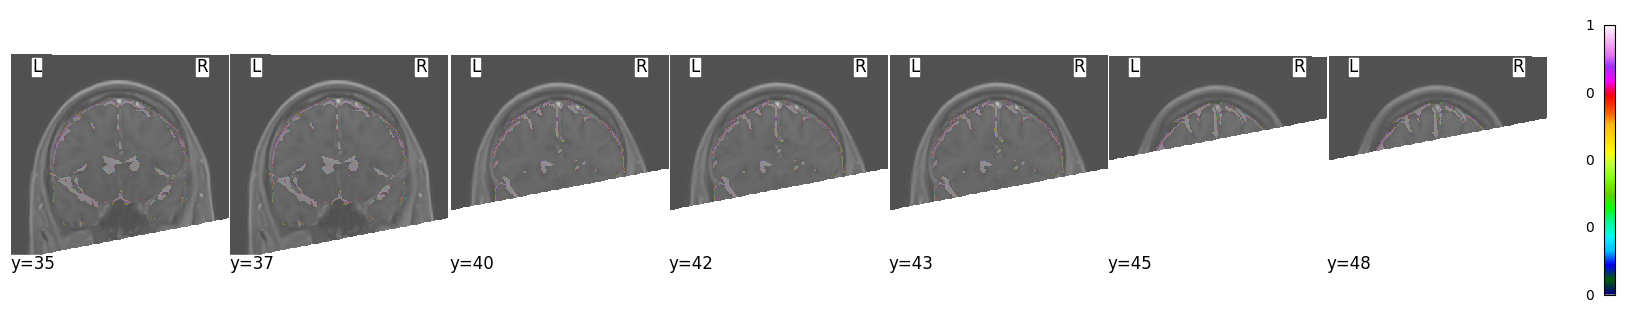

In [6]:
baseline_dce_mean_mask_wmh = nib.load(r'Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/derivatives/DeepWMH/sub001_baseline_DCE/002_Segmentations/003_postproc_fov/sub001.nii.gz')
plotting.plot_roi(baseline_dce_mean_mask_csf, baseline_dce_mean, display_mode="y", black_bg=False, colorbar=True, alpha=0.3)

In [11]:
followup_dce_mean = nib.load(r'Z:/2023 VNSiSVD/data/data_neuroimage_DCE/processed/002_spm12_realign&seg/followup/meant1_vibe_cor_dynamic_waterext_11.nii')
followup_dce_mean_mask_gm = nib.load(r'Z:/2023 VNSiSVD/data/data_neuroimage_DCE/processed/002_spm12_realign&seg/followup/c1meant1_vibe_cor_dynamic_waterext_11.nii')
followup_dce_mean_mask_wm = nib.load(r'Z:/2023 VNSiSVD/data/data_neuroimage_DCE/processed/002_spm12_realign&seg/followup/c2meant1_vibe_cor_dynamic_waterext_11.nii')
followup_dce_mean_mask_csf = nib.load(r'Z:/2023 VNSiSVD/data/data_neuroimage_DCE/processed/002_spm12_realign&seg/followup/c3meant1_vibe_cor_dynamic_waterext_11.nii')

D:\Environments\anaconda3\envs\NI\Lib\site-packages\numpy\ma\core.py:2846: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


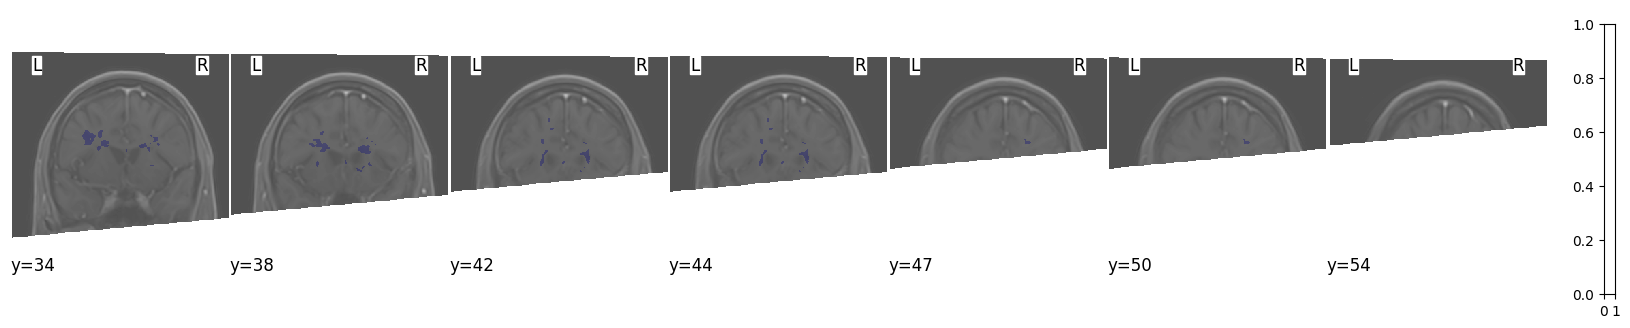

In [12]:
followup_dce_mean_mask_wmh = nib.load(r'Z:/2023 VNSiSVD/data/data_neuroimage_trial/bids/derivatives/DeepWMH/sub001_6m_DCE/002_Segmentations/003_postproc_fov/sub001.nii.gz')
plotting.plot_roi(followup_dce_mean_mask_wmh, followup_dce_mean, display_mode="y", black_bg=False, colorbar=True, alpha=0.3)

D:\Environments\anaconda3\envs\NI\Lib\site-packages\numpy\ma\core.py:2846: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


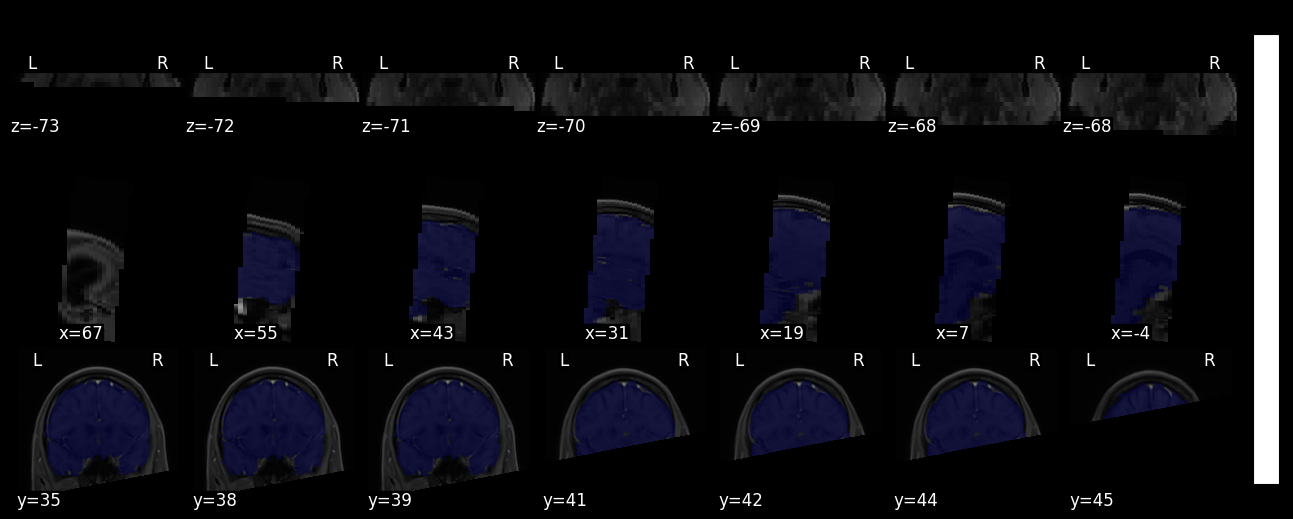

In [ ]:
baseline_dce_mean_mask_brain = ((baseline_dce_mean_mask_gm.get_fdata() > 0) | (baseline_dce_mean_mask_wm.get_fdata() > 0) | (baseline_dce_mean_mask_csf.get_fdata() > 0)).astype(np.uint8)   # True→1，False→0
#baseline_dce_mean_mask_brain = ndimage.binary_closing(baseline_dce_mean_mask_brain, iterations=1).astype(np.uint8)
baseline_dce_mean_mask_brain = nib.Nifti1Image(baseline_dce_mean_mask_brain, affine=baseline_dce_mean.affine)
plotting.plot_roi(baseline_dce_mean_mask_brain, baseline_dce_mean, display_mode="mosaic", black_bg=True, colorbar=True, alpha=0.3)

D:\Environments\anaconda3\envs\NI\Lib\site-packages\numpy\ma\core.py:2846: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


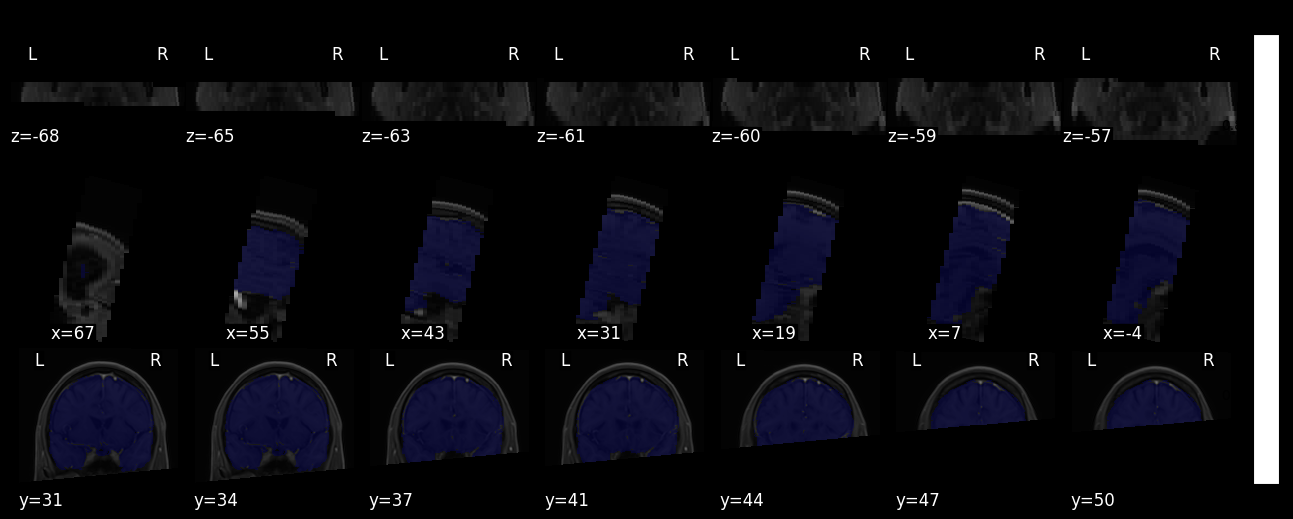

In [32]:
followup_dce_mean_mask_brain = ((followup_dce_mean_mask_gm.get_fdata() > 0) | (followup_dce_mean_mask_wm.get_fdata() > 0) | (followup_dce_mean_mask_csf.get_fdata() > 0)).astype(np.uint8)   # True→1，False→0
#followup_dce_mean_mask_brain = ndimage.binary_closing(followup_dce_mean_mask_brain, iterations=1).astype(np.uint8)
followup_dce_mean_mask_brain = nib.Nifti1Image(followup_dce_mean_mask_brain, affine=followup_dce_mean.affine)
plotting.plot_roi(followup_dce_mean_mask_brain, followup_dce_mean, display_mode="mosaic", black_bg=True, colorbar=True, alpha=0.3)

In [ ]:
nib.save(baseline_dce_mean_mask_brain, r'Z:/2023 VNSiSVD/data/data_neuroimage_DCE/processed/002_spm12_realign&seg/baseline/baseline_dce_mean_mask_brain.nii')
nib.save(followup_dce_mean_mask_brain, r'Z:/2023 VNSiSVD/data/data_neuroimage_DCE/processed/002_spm12_realign&seg/followup/followup_dce_mean_mask_brain.nii')